In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sunpy.visualization.colormaps as sunpycm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from sunpy.visualization.colormaps import color_tables
from omegaconf import OmegaConf

from sdofmv2.core import SDOMLDataModule, MAE, inverse_log_norm
from sdofmv2.tasks.missing_data import MissingDataModel

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

In [3]:
cfg = OmegaConf.load("../../../../configs/downstream/missing_channel_sdofmv2_ALL.yaml")

cache_dir = "../../../../assets/cache/missing_channel/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=(
        os.path.join(
            cfg.data.sdoml.base_directory,
            cfg.data.sdoml.sub_directory.hmi,
        )
        if cfg.data.sdoml.sub_directory.hmi
        else None
    ),
    aia_path=(
        os.path.join(
            cfg.data.sdoml.base_directory,
            cfg.data.sdoml.sub_directory.aia,
        )
        if cfg.data.sdoml.sub_directory.aia
        else None
    ),
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    pin_memory=cfg.data.pin_memory,
    persistent_workers=cfg.data.persistent_workers,
    multiprocessing_context=cfg.data.multiprocessing_context,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    hmi_mask_path=cfg.data.hmi_mask,
    apply_mask=cfg.data.sdoml.apply_mask,
    num_frames=cfg.data.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    precision=cfg.experiment.precision,
)
data_module.setup()
channels = data_module.wavelengths + data_module.components

2026-06-09 01:46:22.358 | INFO     | sdofmv2.core.datamodule:setup:636 - Train dataloader is ready!
2026-06-09 01:46:22.359 | INFO     | sdofmv2.core.datamodule:setup:637 - Dataset size: 27049
2026-06-09 01:46:22.365 | INFO     | sdofmv2.core.datamodule:setup:655 - Validation dataloader is ready!
2026-06-09 01:46:22.366 | INFO     | sdofmv2.core.datamodule:setup:656 - Dataset size: 2749
2026-06-09 01:46:22.372 | INFO     | sdofmv2.core.datamodule:setup:674 - test dataloader is ready!
2026-06-09 01:46:22.373 | INFO     | sdofmv2.core.datamodule:setup:675 - Dataset size: 2888


In [4]:
backbone = MAE.load_from_checkpoint(
    os.path.join("../../../../assets/checkpoints/backbone/ALL/", cfg.experiment.backbone.weight_name),
    map_location="cpu",
    weights_only=False,
)

model = MissingDataModel.load_from_checkpoint(
    "../../../../assets/checkpoints/missing_channel/missing_channel_best_validation_sdofmv2_all.ckpt",
    backbone=backbone,
    map_location="cpu",
    weights_only=False,
)

In [5]:
cms_dict = {
    "131A": sunpycm.cmlist.get("sdoaia131"),
    "1600A": sunpycm.cmlist.get("sdoaia1600"),
    "1700A": sunpycm.cmlist.get("sdoaia1700"),
    "171A": sunpycm.cmlist.get("sdoaia171"),
    "193A": sunpycm.cmlist.get("sdoaia193"),
    "211A": sunpycm.cmlist.get("sdoaia211"),
    "304A": sunpycm.cmlist.get("sdoaia304"),
    "335A": sunpycm.cmlist.get("sdoaia335"),
    "94A": sunpycm.cmlist.get("sdoaia94"),
    "Bx": color_tables.hmi_mag_color_table(),
    "By": color_tables.hmi_mag_color_table(),
    "Bz": color_tables.hmi_mag_color_table(),
}

In [28]:
# Input
timestamps = ["2019-12-25 00:12:00"]
img_indices = [
    data_module.test_ds.aligndata.index.get_loc(pd.to_datetime(i_time)) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]
print(f"Datetime: {ts}")

Datetime: [Timestamp('2019-12-25 00:12:00')]


In [29]:
x_set_denorm_corrupted = x_set.clone().detach().cpu().numpy()
x_set_denorm = x_set.clone().detach().cpu().numpy()


# inverse transformation of hmi for visualization
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(channels[-3:]):

        x_set_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            x_set_denorm[i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

        x_set_denorm_corrupted[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            x_set_denorm_corrupted[i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

# Use config for corrupted_channel_index, fallback to 5
corrupted_channel = cfg.experiment.get("corrupted_channel_index", 5)
x_set_denorm_corrupted[:, corrupted_channel, :, :, :] = 0 # visualization for corrupted input
x_set[:, corrupted_channel, :, :, :] = 0 # model input

# output denorm
loss, output, mask = model(x_set)
output_denorm = output.clone().detach().cpu().numpy()
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(channels[-3:]):

        output_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            output_denorm[i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

/tmp/ipykernel_61968/3952086406.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


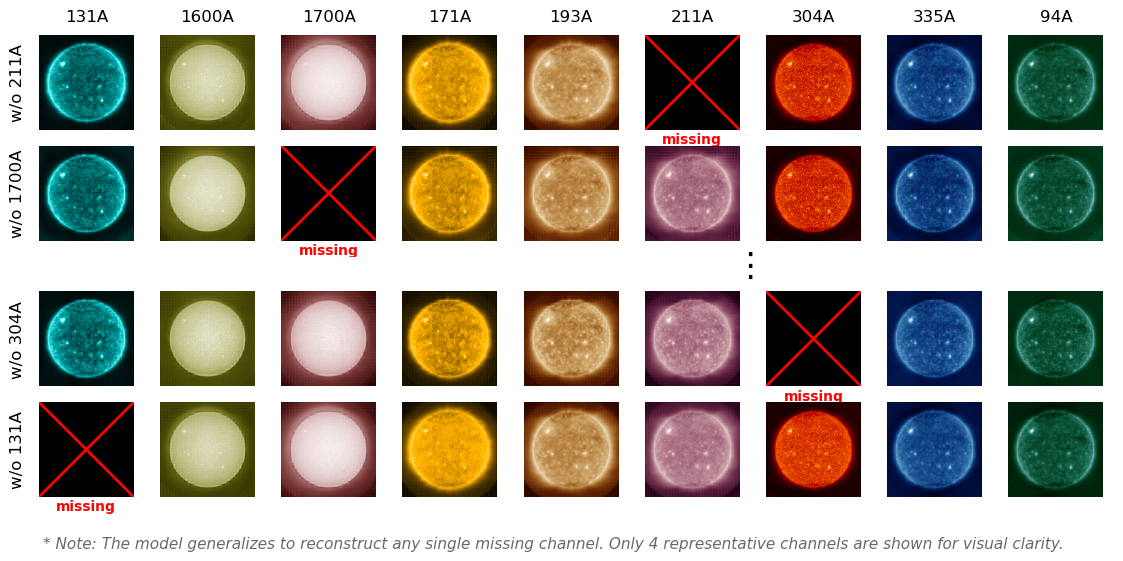

In [30]:
target_corruptions = [5, 2, None, 6, 0]
outputs_to_plot = []

# model outputs for each missing channel scenario
for c in target_corruptions:
    if c is None:
        outputs_to_plot.append(None)
        continue

    x_input = x_set.clone()
    x_input[:, c, :, :, :] = 0 

    _, output, _ = model(x_input)
    output_denorm = output.clone().detach().cpu().numpy()

    # Inverse transformation of HMI for visualization
    for i_img in range(x_input.shape[0]):
        for ch_id, ch in enumerate(channels[-3:]):
            output_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
                output_denorm[i_img, ch_id+9, 0, :, :],
                data_module.normalization_stat,
                ch,
                cfg.data.sdoml.normalization.scaler_factor,
            )
    output_denorm[:, c, :, :, :] = 0 
    outputs_to_plot.append(output_denorm)


norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)
fig, axes = plt.subplots(
    nrows=5, 
    ncols=9, 
    figsize=(14, 6), 
    gridspec_kw={
        'height_ratios': [1, 1, 0.2, 1, 1],
        'wspace': 0.05,  # <-- Reduces horizontal gap between columns
        'hspace': 0.20   # <-- Reduces vertical gap between rows
    }
)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for row_idx, corr_ch in enumerate(target_corruptions):
    
    # dots
    if corr_ch is None:
        axes[row_idx, 5].text(
            1.0, 0.5, 
            "⋮", 
            fontsize=24, 
            ha="center", 
            va="center")
        
        continue

    output_denorm = outputs_to_plot[row_idx]

    for i_ch, ch in enumerate(channels[:9]):
        
        # Add column titles only to the top row
        if row_idx == 0:
            axes[0, i_ch].set_title(f"{ch}", fontsize=12, pad=10)

        # Add row labels to the first column
        if i_ch == 0:
            axes[row_idx, 0].set_ylabel(f"w/o {channels[corr_ch]}", fontsize=12, labelpad=10)
            axes[row_idx, 0].spines['left'].set_visible(False)

        # If this is the missing channel, draw the red "X" on a black background
        if i_ch == corr_ch:
            axes[row_idx, i_ch].set_facecolor("black")
            axes[row_idx, i_ch].set_aspect("equal")
            axes[row_idx, i_ch].set_xlim(0, 1)
            axes[row_idx, i_ch].set_ylim(0, 1)
            axes[row_idx, i_ch].plot([0, 1], [0, 1], color="red", linewidth=2)
            axes[row_idx, i_ch].plot([0, 1], [1, 0], color="red", linewidth=2)
            axes[row_idx, i_ch].text(
                0.5,
                -0.1,
                "missing",
                color="red",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
            )
        else:
            # Otherwise, plot the actual model output for the remaining channels
            axes[row_idx, i_ch].imshow(
                output_denorm[0, i_ch, 0, :, :], 
                cmap=cms_dict[ch], 
                norm=norm if i_ch >= 9 else None
            )

# Add the built-in caption
fig.text(
    0.5, 0.02, # X, Y coordinates (0.5 is perfectly centered horizontally, 0.02 is near the bottom)
    "* Note: The model generalizes to reconstruct any single missing channel. Only 4 representative channels are shown for visual clarity.",
    ha="center", 
    va="bottom", 
    fontsize=11, 
    style="italic", 
    color="dimgray"
)

plt.tight_layout()
plt.savefig("DS_missing_data_img_result_with_4missing.pdf", dpi=300, bbox_inches="tight")
plt.show()